# Identification
Please indicate your name and parcours (e.g.: IMA, DIGIT, BIM, DAC, ..., Erasmus)

### Student : Arafat Islam 
### Parcours : DIGIT (IMA)

### importing all the necessary libraries so that I don't need to call it later.

In [81]:
from PIL import Image # this library I need to access and manipulate the image.
import numpy as np # this library I need to do calculation and manipulation of matrices.
import matplotlib.pyplot as plt # this library to visualize the data, matrix to image, histogram etc.

# Practical work 1: introduction and image enhancement 

- Quick start for Python (10 minutes!) : https://www.stavros.io/tutorials/python/
- Quick start for Numpy : https://numpy.org/devdocs/user/quickstart.html#
- For Matlab users: Numpy is very similar but with some important difference, see http://mathesaurus.sourceforge.net/matlab-numpy.html.
- Keep in mind that in Python, exception of variable of scalar type, all is reference and affectation is not a copy. 


## Short introduction to image processing with Python

Help: use the function `help()` to get information on a Python objet. 

Images are stored as arrays that is the default type of the `numpy` module. Defaut type of array elements is `float64` according to the IEEE754 norm. Special float values are defined: infinity (`inf`) and undefined (`nan`, *not a number*), and some numerical constants, such as $\pi$.
 


In [82]:
# predefined constants
print(np.inf,np.nan,np.pi)

# some values
print( 1., 1e10, -1.2e-3)


inf nan 3.141592653589793
1.0 10000000000.0 -0.0012


### Creating an array: several ways.

1. From a list of values (formally any Python iterable object). Elements of an array have the same **type**, determined by Numpy:

In [83]:
V = np.array([1,2,3])
M = np.array([[1,2,3],[4,5,6.]])
print ("V is of type",V.dtype)
print ("M is of type",M.dtype)

V is of type int32
M is of type float64


2. Without values: Numpy has constructors such as `empty()`, `zeros()`, `ones()`... Shape should be given (see below). Important: `empty()` does not initialize array elements.

In [84]:
I = np.zeros((3,4))
print(I)
J = np.empty((4,3))
print(J)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


3. From a sequence, prefer `arange()` from numpy to `range()` from python.

In [85]:
print(np.arange(10))
print(np.arange(0,10,2))
print(np.arange(9,-1,-.5))

[0 1 2 3 4 5 6 7 8 9]
[0 2 4 6 8]
[ 9.   8.5  8.   7.5  7.   6.5  6.   5.5  5.   4.5  4.   3.5  3.   2.5
  2.   1.5  1.   0.5  0.  -0.5]


### Shape of an array

Shape decribes the number of elements for each dimension. A vector is of dimension 1, a matrix is of dimension 2. Superior dimensions are possible. Shape is not size that is the number of elements of an array. Type of shape is always a tuple of integers. With previous example: 

In [86]:
print(I.shape, I.size)
print(J.shape, J.size)
print(V.shape, V.size)

(3, 4) 12
(4, 3) 12
(3,) 3


An important function/method is `reshape()` to change the shape of an array. Typical usage of `reshape()` is to transform a vector into a matrix or reciprocally. 

In [87]:
K = np.arange(12).reshape((3,4))
print(K)
print(np.reshape(K,(12)))
print(K.reshape((2,2,3)))

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### Elements of an array

Access element by indices: two syntaxe are possible, the first given in the example is prefered. Negative index is possible with the same meanning of Python list.

In [88]:
I = np.arange(12).reshape((3,4))
print(I[1,2])
print(I[0][0])
print(I[-1,0])

6
0
8


Access by group of indices using the operator `:` allows to extract subarray. General syntaxe is `start:end:step` and it is very powerfull:

In [89]:
print('extract the first line')
print(I[0,:])
print(I[0,0:])
print(I[0,::])
print(I[0,::1])

print('extract center of the array')
print(I[1:3,1:3])

print('extract elements with even indices')
print(I[::2,::2])

print('print the horizontal mirror of an array')
print(I[:,::-1])


extract the first line
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]
extract center of the array
[[ 5  6]
 [ 9 10]]
extract elements with even indices
[[ 0  2]
 [ 8 10]]
print the horizontal mirror of an array
[[ 3  2  1  0]
 [ 7  6  5  4]
 [11 10  9  8]]


### Array arithmetic

Operators and functions can be applied to arrays. Mostly, operations are element-wise (i.e. applied element by element). The consequence is arrays should have the same shape. One operand can also be scalar in most of time.

In [90]:
A = np.arange(12).reshape((3,4))
B = 2 * A + 1
C = A + B
D = np.cos(2*np.pi*A/12)

print (D)
print (D**2)
print (D>0)

[[ 1.00000000e+00  8.66025404e-01  5.00000000e-01  6.12323400e-17]
 [-5.00000000e-01 -8.66025404e-01 -1.00000000e+00 -8.66025404e-01]
 [-5.00000000e-01 -1.83697020e-16  5.00000000e-01  8.66025404e-01]]
[[1.00000000e+00 7.50000000e-01 2.50000000e-01 3.74939946e-33]
 [2.50000000e-01 7.50000000e-01 1.00000000e+00 7.50000000e-01]
 [2.50000000e-01 3.37445951e-32 2.50000000e-01 7.50000000e-01]]
[[ True  True  True  True]
 [False False False False]
 [False False  True  True]]


Array may be viewed as matrix, we can make some linear algebraic manipulation. For example, `np.matmul()` is the matrix multiplication. It can be used to build matrix from vector. An example, using the transpose operator `T`. 

In [91]:
L = np.arange(1,6).reshape((1,5))
# transpose of L. Warning: C remains a reference to L
C = L.T
# This could be better if your want to touch L 
C = L.T.copy()

print("A 5*5 matrix:")
print(np.matmul(C,L))

print("A dot product, but result is a matrix:")
print(np.matmul(L,C))
print(np.matmul(L,C)[0,0])

print("dot() is prefered with vectors:")
V = np.arange(1,6)
print(V.dot(V))
print(np.dot(V,V))

A 5*5 matrix:
[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]
A dot product, but result is a matrix:
[[55]]
55
dot() is prefered with vectors:
55
55


### Images

We make use of PIL module (https://pillow.readthedocs.io/en/stable/reference/Image.html) to load and write an image and easily converted to Numpy array. Be careful: array type depends on image.

In [92]:
# reading an image and convert to array
myimage = np.array(Image.open('img/image.png'))

# write an image (alternative format) from an array
Image.fromarray(myimage).save('img/image.jpg')

Array can be displayed as an image using Matplotlib module. Here a short example:

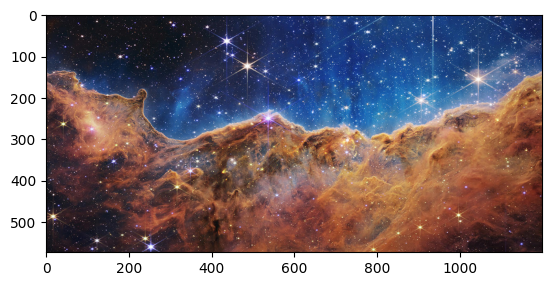

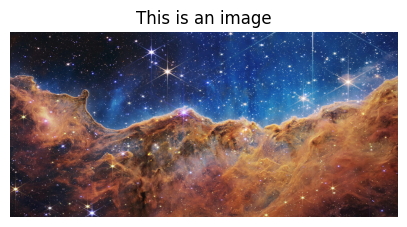

In [93]:
# minimal example:
plt.imshow(myimage)
plt.show()

# with more controls:
w,h=400,400
plt.figure(figsize=(w/80,h/80))  # optional, to control the size of figure (unit: pixel)
plt.gray() # optional call to display image using a gray colormap
plt.title('This is an image') # optional: add a title
plt.axis('off') # optional: remove axes
plt.imshow(myimage)
plt.show()


See also:
- https://matplotlib.org/3.1.1/tutorials/introductory/images.html
- https://matplotlib.org/stable/gallery/images_contours_and_fields/image_demo.html

## Exercise 1
In this exercise, we work with image `img/moon.png`. If possible give two solutions: one with loops (for, while, ...) and one without loops using Numpy arithmetic avoiding ad-hoc Numpy functions such as `np.where()`. 

1. Write and test a function `openImage()` getting an image filename as argument and returning the array of pixel values.

In [94]:
def openImage(fname):
    """ str -> Array 
    (notation above means the function gets a string argument and returns an Array object)
    """
    print("\nThe original image: \n")
    im = Image.open(fname)
    display(im)

    print("\nThe original image in Array Format: \n")
    myimage_array = np.array(Image.open(fname))
    print(myimage_array)
    print("\nShape: ", myimage_array.shape)
    print("Size: ", myimage_array.size)
    print("Type: ",type(myimage_array))

    # returning this array as it will be require for the next steps in different functions
    return myimage_array

2. Write and test a function `countPixels()` getting an array and an integer `k` as arguments and returning the number of pixels having the value `k`.

In [95]:
def countPixels(I,k):
    """ Array*int -> int"""
    k_count = 0
    for x in np.nditer(I):
        if x == k:
            k_count += 1

    print(f"\nNumber of Pixel that has value {k} is : {k_count}")

3. Write and test a function `replacePixels()` getting an array and two intergers and replacing pixels having `k1`value to `k2` value and returning the new array. Be aware to not modify `I`.

In [96]:
def replacePixels(I,k1,k2):
    """ Array*int*int -> Array """
    I_new = np.copy(I) # I have used copy() function so that it will not change the original matrix.
    I_new [I_new == k1] = k2
    print ("Midified array: \n", I_new)
    print("\nOriginal array: \n", I)
    return I_new
    

4. Write and test a function `normalizeImage()` getting an array and two integers `k1` and `k2` and returning an array with elements normalized to the interval $[k_1,k_2]$. 

### I did it with Madam Clara Bremond Martin’s guidance. I tried two approaches: one with dynamic range and one without.

### following the equation from the lecture slide:
![title](img/eqn_1.png)

In [97]:
def normalizeImage(I,k1,k2):
    """ Array*int*int -> Array """
    # this part I did using min-max method
    I_new = np.copy(I)
    i_min = I_new.min()
    i_max = I_new.max()
    normalized_I = (I_new.astype(np.float64) - float(i_min)) / float(i_max - i_min)
    normalized_I = k1 + normalized_I * (k2 - k1)
    normalized_I= np.rint(normalized_I).astype(np.int32)
    #vizualize_image(normalized_I, title= f"Min-max method: Normalized image in {k1} to {k2} range")
    return normalized_I


### `normalizeImage()` function considering `Dynamic Range L`

In [98]:
def normalizeImage_with_dynamic_range(I, k1, k2):
    I_new = np.copy(I)
    i_min, i_max = I_new.min(), I_new.max()
    L = k2 - k1 + 1
    normalized_I = k1 + ((I_new - i_min) * (L - 1)) / (i_max - i_min)
    normalized_I= np.rint(normalized_I).astype(np.int32)
    #vizualize_image(normalized_I, title= f"Considering Dynamic Range: Normalized image in {k1} to {k2} range")
    return normalized_I

5. Write and test a function `inverteImage()` getting an array and returning and arry having inverted pixel values (i.e. the transform $k \mapsto 255-k$

In [99]:
def inverteImage(I):
    """ Array -> Array """
    I_new = np.copy(I)
    I_new = (255 - I_new.astype(np.int32)).astype(np.int32)  # k = 255 - k
    #vizualize_image(I_new, title= f"Inverted Image")
    return I_new

6. Write and test a function `computeHistogram()` getting an array and returning its histogram. Type of histogram can be an array or a list. It is forbidden to use an histogram method from a Python module. Is it possible to compute the histogram without explicitely visiting array pixels? 

## My answer to the question above: 
#### Yes, it possible to compute the histogram without explicitely visiting array pixels. In the lecture we read that a histogram is just the distribution of intensity values. Instead of checking each pixel one by one we can use mathematical or vectorized operations to count how many times each value appears, so we don’t need to explicitly loop over all pixels.

In [100]:
def computeHistogram(I):
    """ Array -> list[int] """
    hist = [0] * 256              # this will help me to store color level for each and every pixel
    rows, cols = I.shape
    for i in range(rows):
        for j in range(cols):
            value = int(I[i, j])  
            if 0 <= value <= 255:
                hist[value] += 1 
    
    #vizualize_histogram(hist, "Historam Visualization")
    return hist

7. Write and test a function `thresholdImage()` getting an array `I` and an integer `s` and returning an array having elements set to 0 if corresponding element of `I` is lower than `s` or 255 otherwise.

### I have followed this approach from the lecture slides:
![title](img/eqn_2.png)

In [101]:
def thresholdImage(I,s):
    """ Array*int -> Array """
    I_new = np.copy(I)
    rows, cols = I_new.shape
    th_img = np.zeros((rows, cols), dtype=np.int32)
    for i in range(rows):
        for j in range(cols):
            if int(I_new[i, j]) < s:
                th_img[i, j] = 0
            else:
                th_img[i, j] = 255

    #vizualize_image(th_img, title= f"Thresholding image ")
    th_img= np.rint(th_img).astype(np.int32)
    return th_img


8. Using previous functions, give a series of instructions to read then to display an image, plot the histogram (one can use `plot()` or `bar()` from `matplotlib.pyplot` module), inverse the image and display it, plot its histogram.

### I need this two functions to visualize the image and histogram, which is being used in different parts of the file code.

In [102]:
## your code start below
def vizualize_image(I, title=None, vmin=None, vmax=None):
    plt.figure()
    if title: plt.title(title)
    plt.axis('off')
    plt.imshow(np.asarray(I), cmap='gray', vmin=vmin, vmax=vmax)
    plt.tight_layout()
    plt.show() 
    
def vizualize_histogram(hist, title=None, color = None):
    plt.figure()
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.bar(np.arange(256), hist, width=1.0,color=color)
    plt.tight_layout()
    plt.show()


The original image: 



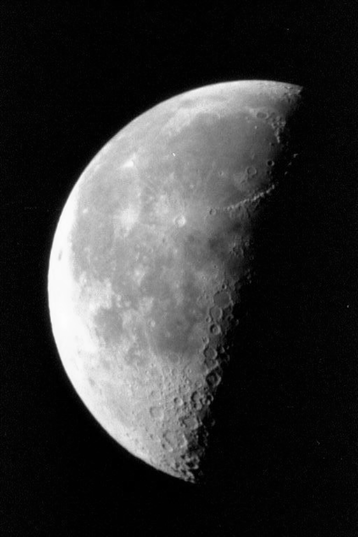


The original image in Array Format: 

[[ 1  3  7 ...  8 16  8]
 [ 3  7  3 ...  4 11 12]
 [ 6  4  6 ...  7  2  3]
 ...
 [ 4  8  8 ...  6  4  8]
 [ 4  8  8 ...  4  6  6]
 [ 2  3  3 ...  6  9  9]]

Shape:  (537, 358)
Size:  192246
Type:  <class 'numpy.ndarray'>

Number of Pixel that has value 3 is : 25408
Midified array: 
 [[  1 100   7 ...   8  16   8]
 [100   7 100 ...   4  11  12]
 [  6   4   6 ...   7   2 100]
 ...
 [  4   8   8 ...   6   4   8]
 [  4   8   8 ...   4   6   6]
 [  2 100 100 ...   6   9   9]]

Original array: 
 [[ 1  3  7 ...  8 16  8]
 [ 3  7  3 ...  4 11 12]
 [ 6  4  6 ...  7  2  3]
 ...
 [ 4  8  8 ...  6  4  8]
 [ 4  8  8 ...  4  6  6]
 [ 2  3  3 ...  6  9  9]]


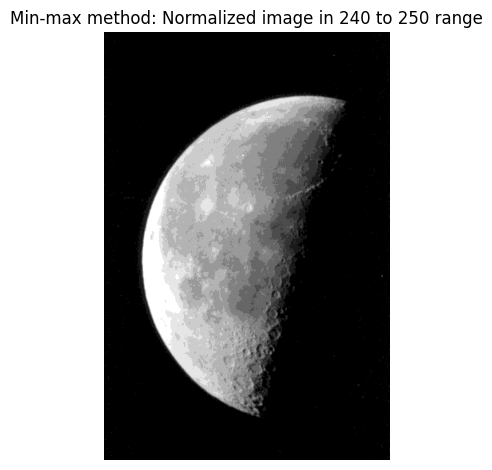

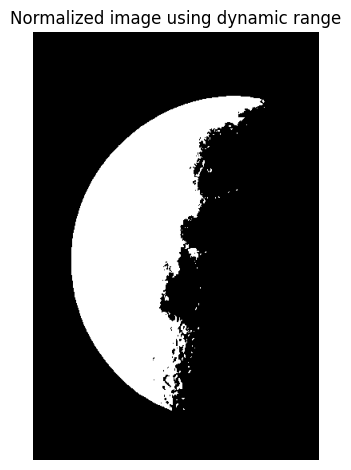

Inverted original moon image: 



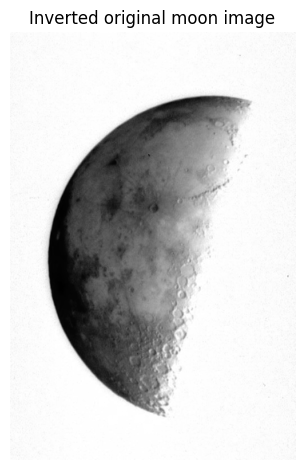

Histogram of the original moon image: 



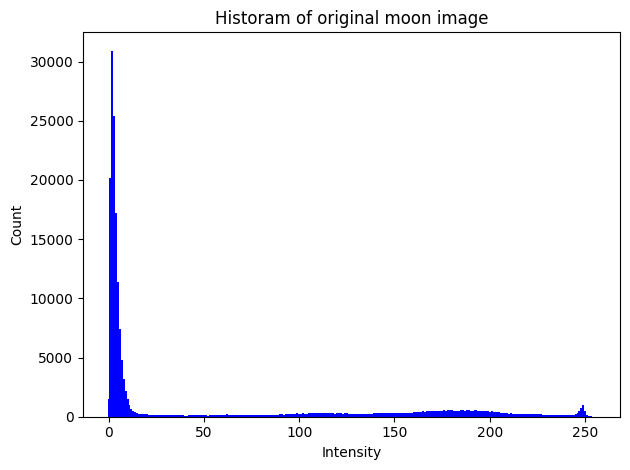

Histogram of the inverted moon image: 



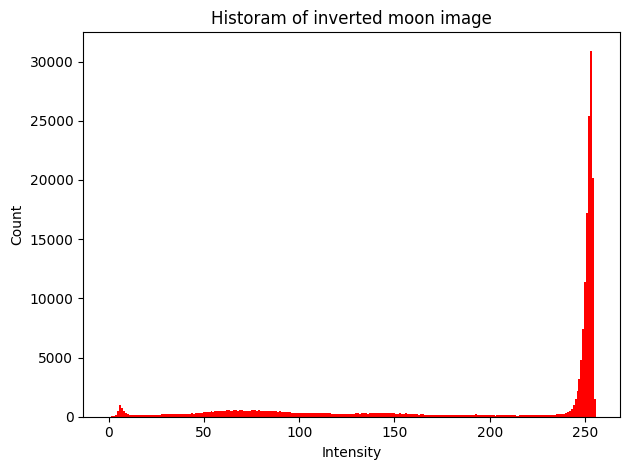

moon image for a thresholding value: 



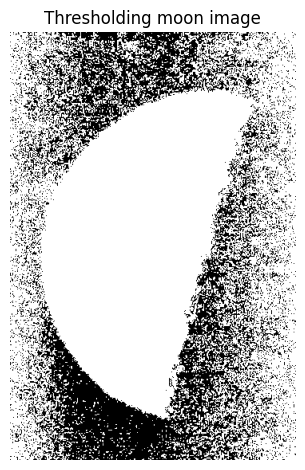

Histogram of the thresholding moon image: 



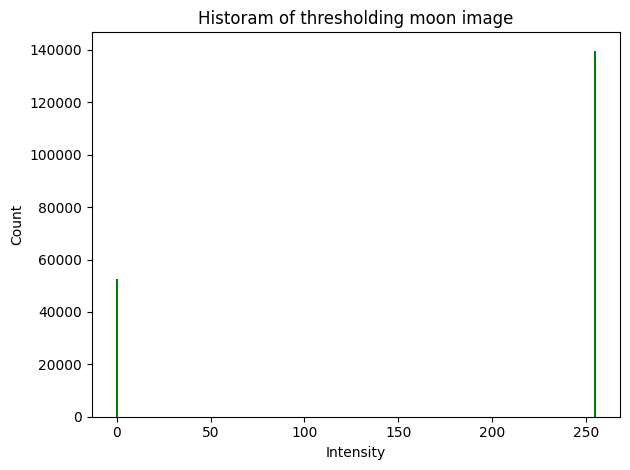

In [103]:
# calling all the functions I have defined before to see if they are working correctly or not.
# converting moon image into and array and also visualizing the moon image
my_image_array = openImage('img/moon.png')

# now counting how many pixel has the value of 3 in the moon image
countPixels(my_image_array, 3)

# repleacing the pixel values who has 3 to 100 in moon image
my_image_array_new = replacePixels(my_image_array,3,100)

# normalizing the value of pixels of the moon image between 240 and 250
k1 = 240
k2 = 250
normalized_img= normalizeImage(my_image_array,k1,k2)
vizualize_image(normalized_img, title= f"Min-max method: Normalized image in {k1} to {k2} range")

# normalizing the value of pixels of the moon image between 0 and 1 using dynamic range also.
n_img_l= normalizeImage_with_dynamic_range(my_image_array,0,1)
vizualize_image(n_img_l, title= f"Normalized image using dynamic range")

#inverting the moon image
print("Inverted original moon image: \n")
inv_img= inverteImage(my_image_array)
vizualize_image(inv_img, title= f"Inverted original moon image")

print("Histogram of the original moon image: \n")
i_histo = computeHistogram(my_image_array)
vizualize_histogram(i_histo, "Historam of original moon image", color = 'blue')

print("Histogram of the inverted moon image: \n")
iv_histo = computeHistogram(inv_img)
vizualize_histogram(iv_histo, "Historam of inverted moon image", color = 'red')

print("moon image for a thresholding value: \n")
s=3
th_img = thresholdImage(my_image_array, s)
vizualize_image(th_img, title= f"Thresholding moon image")


print("Histogram of the thresholding moon image: \n")
histo_th_img=computeHistogram(th_img)
vizualize_histogram(histo_th_img, "Historam of thresholding moon image",color= 'green')


9. Give a series of instructions to read and display an image, plot the histogram, normalize the image to the interval $[10,50]$, compute the new histogram, display the image and the histogram. Remark: `imshow()` normalizes image. To avoid this and see the effect of the normalization, use `imshow()` with parameters `vmin=0,vmax=255`. Comment the results.

### Now i will do all the steps of the "pout.png" image


The original image: 



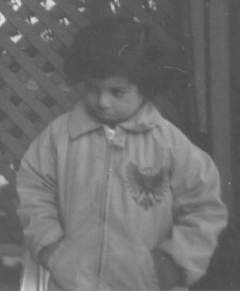


The original image in Array Format: 

[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Shape:  (291, 240)
Size:  69840
Type:  <class 'numpy.ndarray'>

Number of Pixel that has value 3 is : 0
Midified array: 
 [[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Original array: 
 [[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]


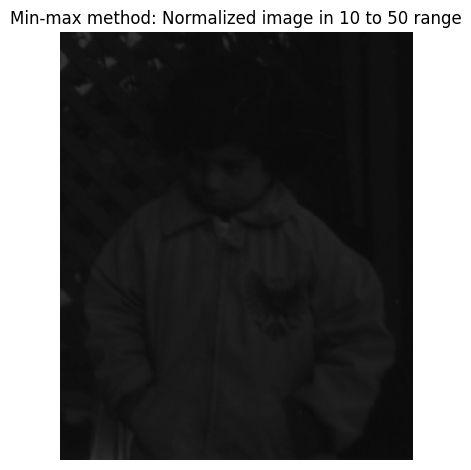

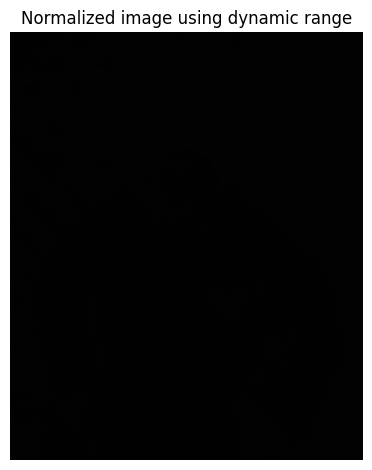

Inverted original pout image: 



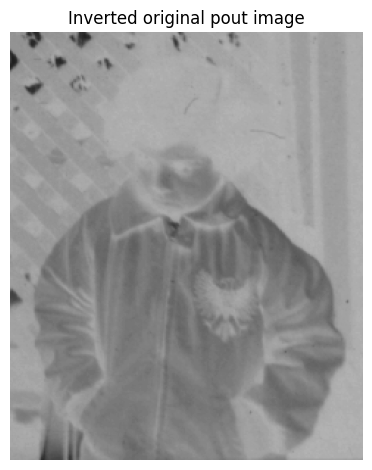

Histogram of the original pout image: 



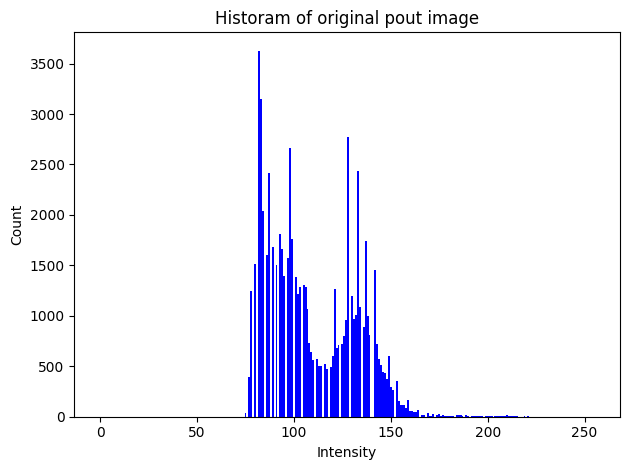

Histogram of the inverted pout image: 



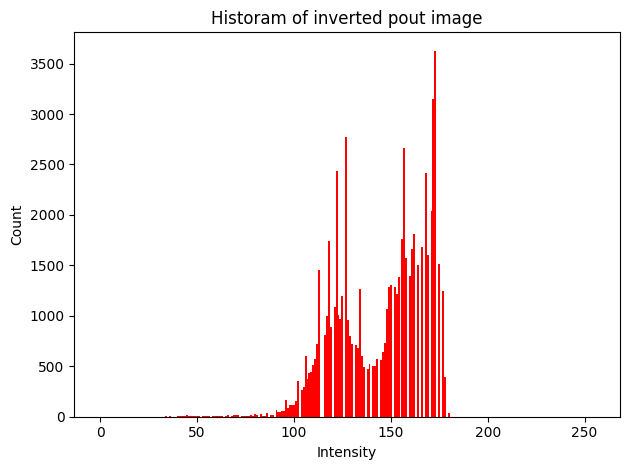

pout image for a thresholding value: 



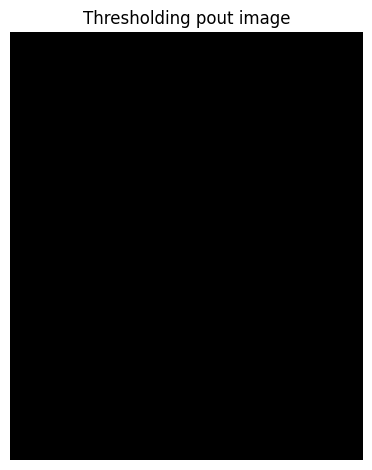

Histogram of the thresholding pout image: 



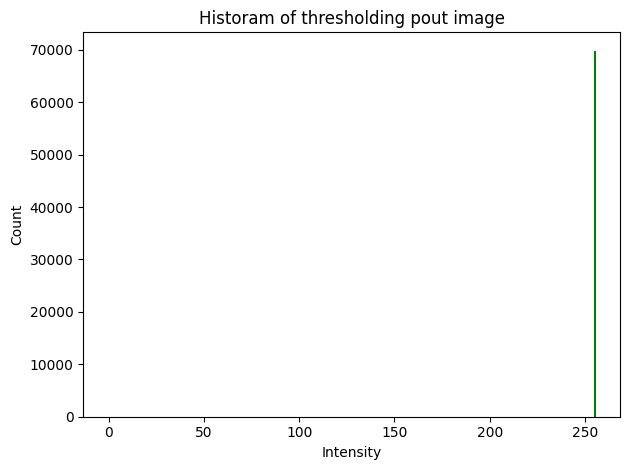

In [104]:
# converting pout image into and array and also visualizing the pout image
my_image_array = openImage('img/pout.png')

# now counting how many pixel has the value of 3 in the pout image
countPixels(my_image_array, 3)

# repleacing the pixel values who has 3 to 100 in pout image
my_image_array_new = replacePixels(my_image_array,3,100)

# normalizing the value of pixels of the pout image between 10 and 50
k1 = 10
k2 = 50
normalized_img= normalizeImage(my_image_array,k1,k2)
vizualize_image(normalized_img, title= f"Min-max method: Normalized image in {k1} to {k2} range",vmin=0,vmax=255)

# normalizing the value of pixels of the pout image between 0 and 255 using dynamic range also.
n_img_l= normalizeImage_with_dynamic_range(my_image_array,0,255)
vizualize_image(n_img_l, title= f"Normalized image using dynamic range",vmin=0,vmax=255)

#inverting the pout image
print("Inverted original pout image: \n")
inv_img= inverteImage(my_image_array)
vizualize_image(inv_img, title= f"Inverted original pout image",vmin=0,vmax=255)

print("Histogram of the original pout image: \n")
i_histo = computeHistogram(my_image_array)
vizualize_histogram(i_histo, "Historam of original pout image", color = 'blue')

print("Histogram of the inverted pout image: \n")
iv_histo = computeHistogram(inv_img)
vizualize_histogram(iv_histo, "Historam of inverted pout image", color = 'red')

print("pout image for a thresholding value: \n")
s=3
th_img = thresholdImage(my_image_array, s)
vizualize_image(th_img, title= f"Thresholding pout image")


print("Histogram of the thresholding pout image: \n")
histo_th_img=computeHistogram(th_img)
vizualize_histogram(histo_th_img, "Historam of thresholding pout image",color= 'green')

10. Same question than 9. remplacing the normalization by a thresholding with parameter $s=127$.


The original image: 



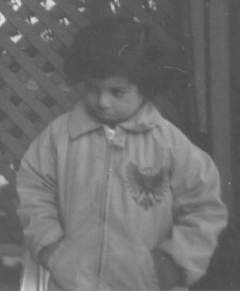


The original image in Array Format: 

[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Shape:  (291, 240)
Size:  69840
Type:  <class 'numpy.ndarray'>

Number of Pixel that has value 3 is : 0
Midified array: 
 [[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Original array: 
 [[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]


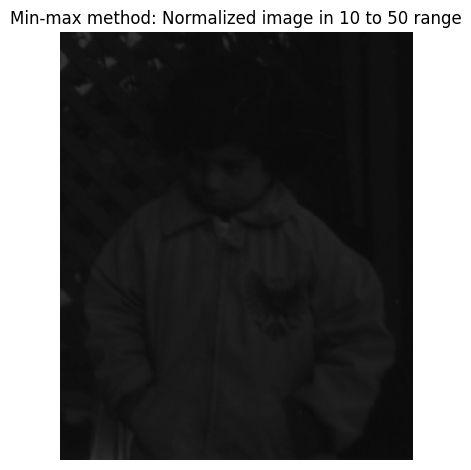

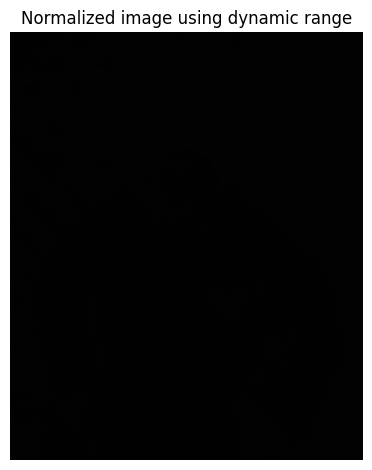

Inverted original pout image: 



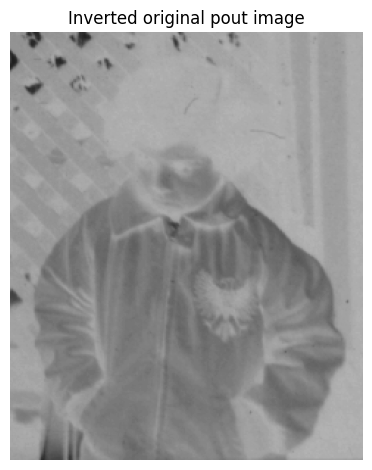

Histogram of the original pout image: 



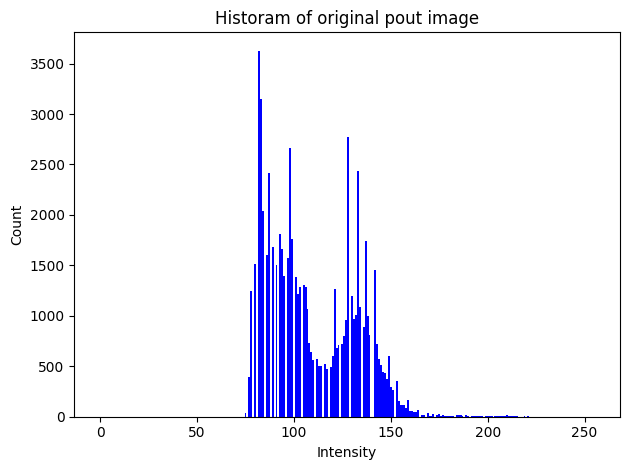

Histogram of the inverted pout image: 



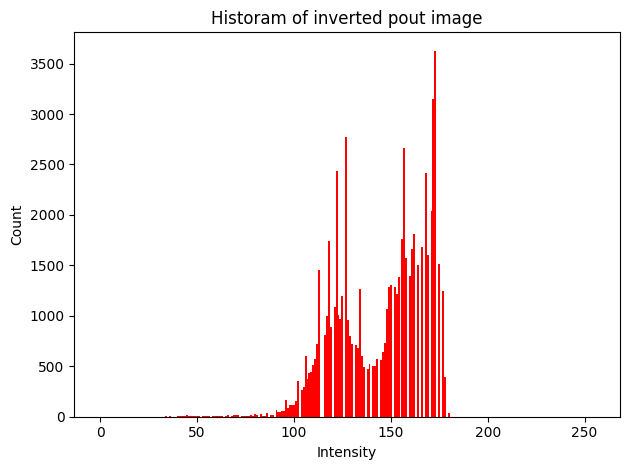

pout image for a thresholding value: 



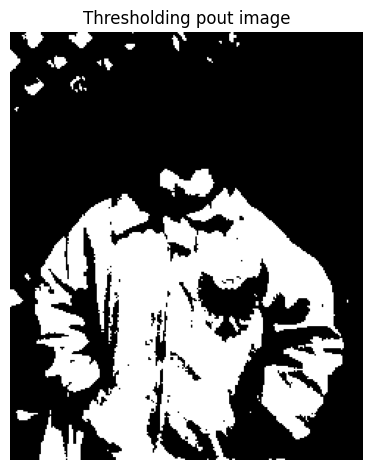

Histogram of the thresholding pout image: 



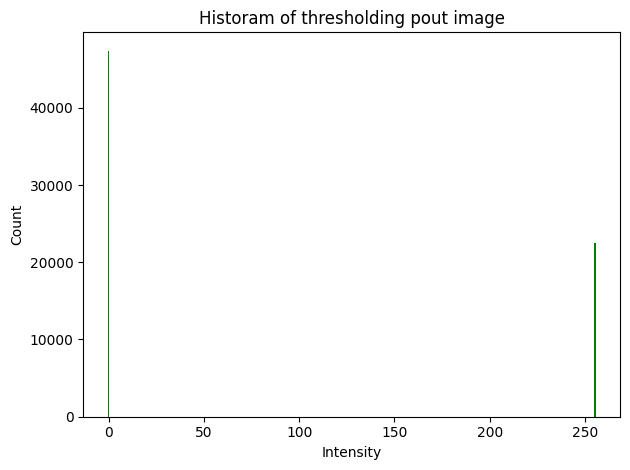

In [105]:
# converting pout image into and array and also visualizing the pout image
my_image_array = openImage('img/pout.png')

# now counting how many pixel has the value of 3 in the pout image
countPixels(my_image_array, 3)

# repleacing the pixel values who has 3 to 100 in pout image
my_image_array_new = replacePixels(my_image_array,3,100)

# normalizing the value of pixels of the pout image between 10 and 50
k1 = 10
k2 = 50
normalized_img= normalizeImage(my_image_array,k1,k2)
vizualize_image(normalized_img, title= f"Min-max method: Normalized image in {k1} to {k2} range",vmin=0,vmax=255)

# normalizing the value of pixels of the pout image between 0 and 255 using dynamic range also.
n_img_l= normalizeImage_with_dynamic_range(my_image_array,0,255)
vizualize_image(n_img_l, title= f"Normalized image using dynamic range",vmin=0,vmax=255)

#inverting the pout image
print("Inverted original pout image: \n")
inv_img= inverteImage(my_image_array)
vizualize_image(inv_img, title= f"Inverted original pout image",vmin=0,vmax=255)

print("Histogram of the original pout image: \n")
i_histo = computeHistogram(my_image_array)
vizualize_histogram(i_histo, "Historam of original pout image", color = 'blue')

print("Histogram of the inverted pout image: \n")
iv_histo = computeHistogram(inv_img)
vizualize_histogram(iv_histo, "Historam of inverted pout image", color = 'red')

print("pout image for a thresholding value: \n")
s=127
th_img = thresholdImage(my_image_array, s)
vizualize_image(th_img, title= f"Thresholding pout image")


print("Histogram of the thresholding pout image: \n")
histo_th_img=computeHistogram(th_img)
vizualize_histogram(histo_th_img, "Historam of thresholding pout image",color= 'green')

## Exercise 2 - generate images

1. Create the array `I` 4 by 4 corresponding to the following image: <div> 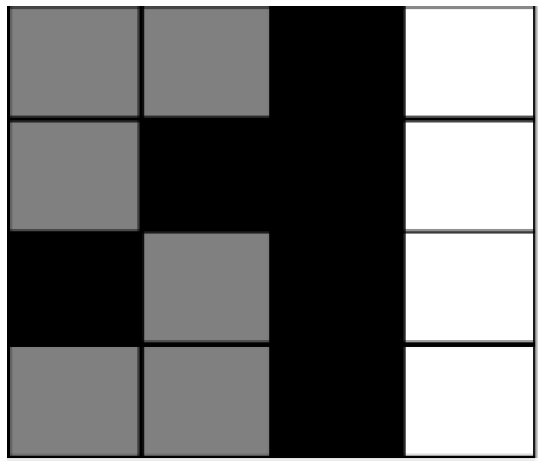 </div> Black pixels have value 0, white pixels value 255, and grey pixels value 127. Display the image using `imshow()` and plot the histogram.

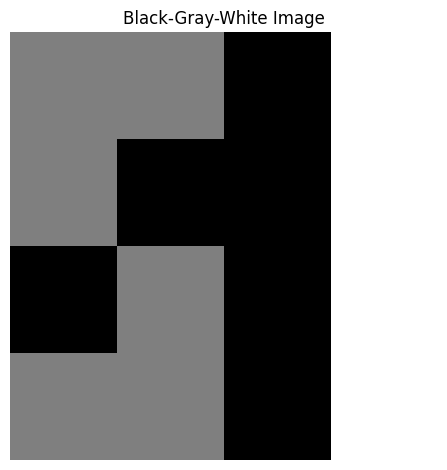

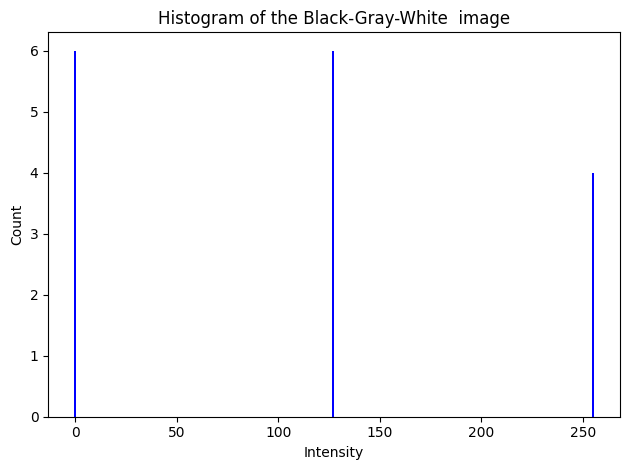

In [106]:
# I have done it manually by assigning each pixel values in the matrix form
I4 = np.array([
    [127, 127,  0, 255],
    [127, 0, 0, 255],
    [0, 127, 0, 255  ],
    [127, 127, 0,   255  ]
], dtype=np.int32)

vizualize_image(I4, title='Black-Gray-White Image', vmin=0, vmax=255)
histo_I4 = computeHistogram(I4)   
vizualize_histogram(histo_I4, title='Histogram of the Black-Gray-White  image', color="blue")



### My previous output is not exactly same as the question asked as there's no black lines between pixels in my generated image as i gave used my previously defined vizualize_image function to visualize this image. Here I did it again with the black line in between the pixels to be as same as the question. I have used the grid lines between pixels.

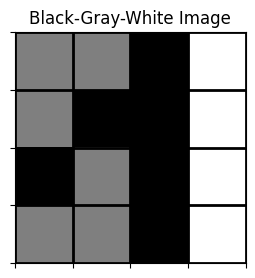

In [107]:
plt.figure(figsize=(3,3))
plt.imshow(I4, cmap="gray", vmin=0, vmax=255)

plt.grid(color='black', linewidth=2)

# Make sure ticks are at pixel boundaries
plt.xticks(np.arange(-0.5, I4.shape[1], 1), [])
plt.yticks(np.arange(-0.5, I4.shape[0], 1), [])

plt.title("Black-Gray-White Image")
plt.show()


2. We want to generate an image having random values. Functions `rand()` and `randn()` from  `numpy.random` module generate an array of given shapes with random values following a uniform distribution on $[0,1[$ and a normal distribution respectively. Create an array of shape 512 by 512 having **integer** elements following a uniform distribution in the set $\{0,1,\cdots,255\}$. We also want to create an array following a Gaussian distribution with a mean of 128 and a standard deviation of 16 and with **integer** values.  Display the images and their histograms. Discuss the results.

### To do this task I have to look into internet and used resources and blog article from medium.com, www.geeksforgeeks.org and http://stackoverflow.com/

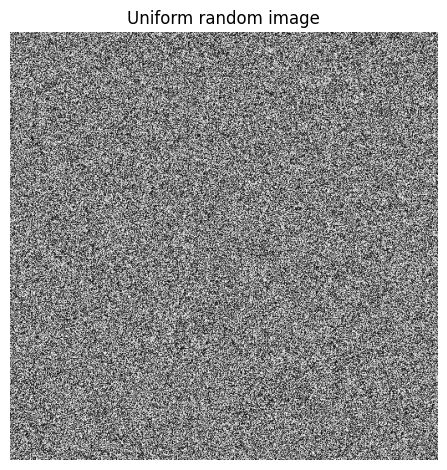

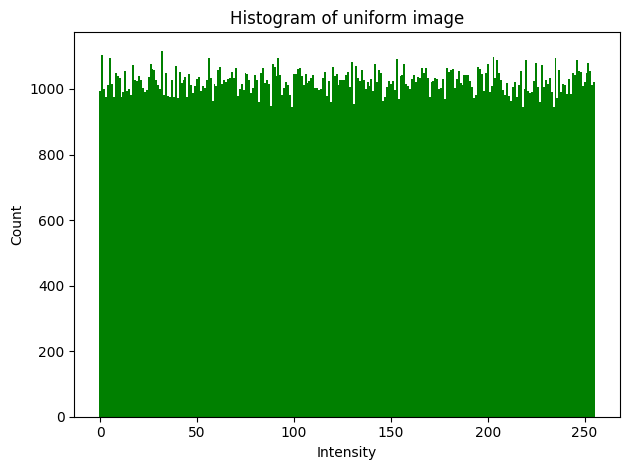

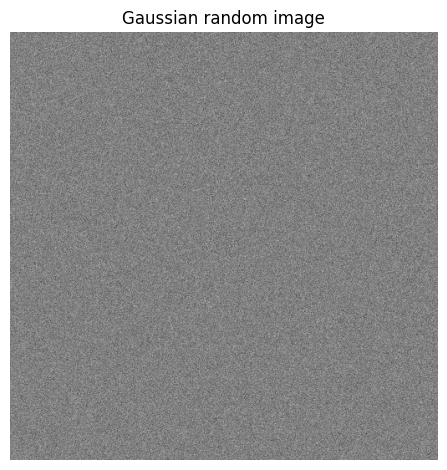

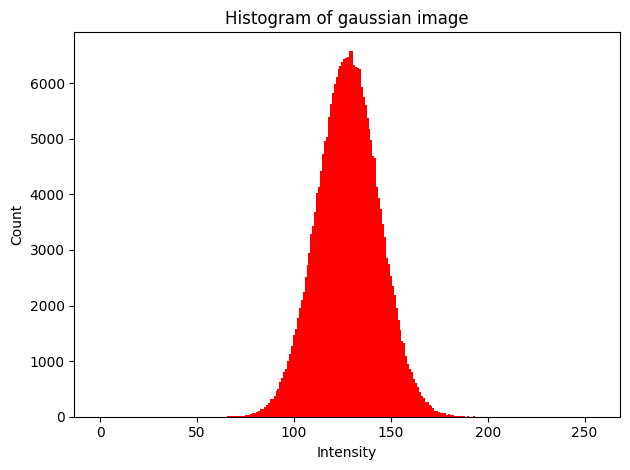

In [108]:
# Set random seed for reproducibility
random_seed = np.random.default_rng(42)

# 512x512 image with integers uniformly distributed in [0 and 255]
uniform_img = random_seed.integers(low=0, high=256, size=(512,512), dtype=np.int32)
# mean is 128
# standard deviation is 16
# 512x512 image with Gaussian distribution
gaussian_img = random_seed.normal(loc=128, scale=16, size=(512,512))
gaussian_img = np.clip(np.rint(gaussian_img), 0, 255).astype(np.int32)

# Visualizing the uniform image and histogram using the method (functions) i have already defined before
vizualize_image(uniform_img, title="Uniform random image", vmin=0, vmax=255)
uniform_hist = computeHistogram(uniform_img)
vizualize_histogram(uniform_hist, title="Histogram of uniform image", color="green")

# Visualizing the gaussian image and histogram using the method i have already defined before
vizualize_image(gaussian_img, title="Gaussian random image", vmin=0, vmax=255)
gaussian_hist = computeHistogram(gaussian_img)
vizualize_histogram(gaussian_hist, title="Histogram of gaussian image", color="red")


#### I have created two random images of size 512 by 512. In the first case, I used a uniform distribution where each pixel is randomly picked between 0 and 255 with equal chance. When I looked at the histogram, it was almost flat because every gray level appeared about the same number of times. The image itself looked like random static noise with no particular structure. In the second case, I used a Gaussian distribution with mean 128 and standard deviation 16. After clipping the values between 0 and 255, the histogram became bell-shaped, centered around 128. This means that most of the pixels are around mid gray, while very dark and very bright pixels are rare. According to what we saw in the lectures, a flat histogram corresponds to values being evenly spread, while a bell-shaped histogram shows values clustering around the middle. Because of this, the uniform image looks like pure noise across all intensity levels, while the Gaussian image looks noisy but mostly gray since the middle intensities dominate.

## Exercise 3: image manipulation
In this exercise, we work with image `img/pout.png`. 

1. Read and display this image


The original image: 



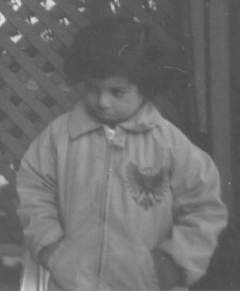


The original image in Array Format: 

[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Shape:  (291, 240)
Size:  69840
Type:  <class 'numpy.ndarray'>


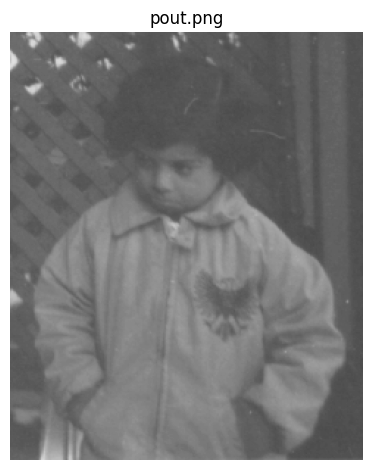

In [109]:
# I can do it in one line (pout = openImage('img/pout.png')), but i also can use try and except method as I'm initially not sure where was the image.
try:
    pout = openImage('img/pout.png')
    vizualize_image(pout, title='pout.png', vmin=0, vmax=255)
except FileNotFoundError:
    print('no img!!')


2. Examine the histogram. Determine the extrema of the image. What can you say about the quality of this image?

Histogram of the original pout image: 



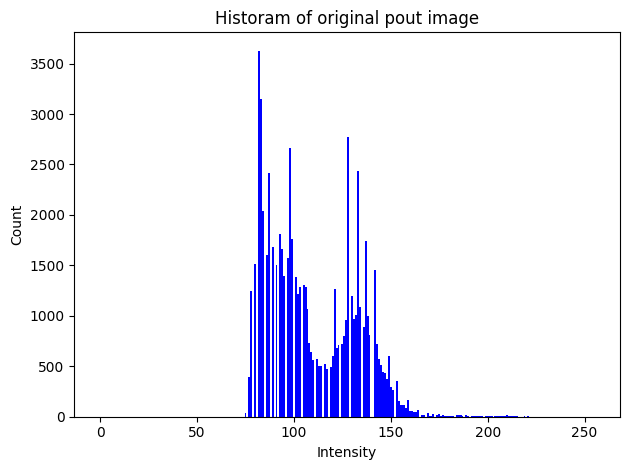

In [110]:
print("Histogram of the original pout image: \n")
i_histo = computeHistogram(my_image_array)
vizualize_histogram(i_histo, "Historam of original pout image", color = 'blue')

##### Looking at the histogram of the pout image, I can see that the pixel values are mostly between about 75 and 170. That means the minimum intensity of the image is around 70 and the maximum is about 160. According to the lecture, if the histogram only covers a small part of the full range [0,255], the image will have low contrast and look flat or dull. This is exactly the case here: the histogram is narrow and shifted to the darker side, so the image looks dark and lacks detail in bright regions. The overall quality of the image is poor because it does not use the full dynamic range of intensities, which reduces the visibility of details.

3. Using functions from Exercice 1, write the function `histogramEqualization()` getting one image, its histogram,  applying an histogram equalization and returning the new image. Test this function on `pout.png` and discuss the result.


The original image: 



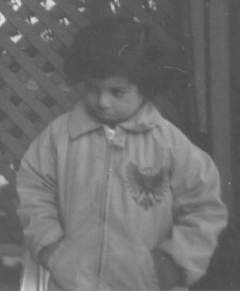


The original image in Array Format: 

[[107 108 107 ...  84  83  83]
 [109 106 108 ...  84  84  86]
 [107 106 110 ...  84  83  83]
 ...
 [ 97  99 101 ...  82  82  83]
 [ 99  98  98 ...  84  84  86]
 [101  99  99 ...  97  97  97]]

Shape:  (291, 240)
Size:  69840
Type:  <class 'numpy.ndarray'>


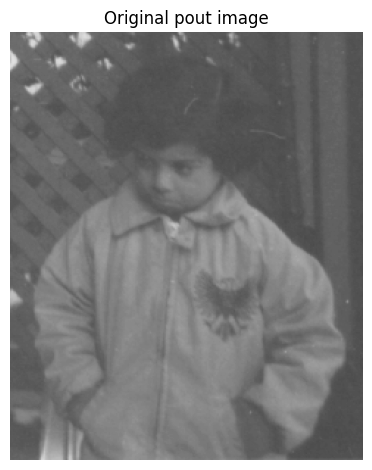

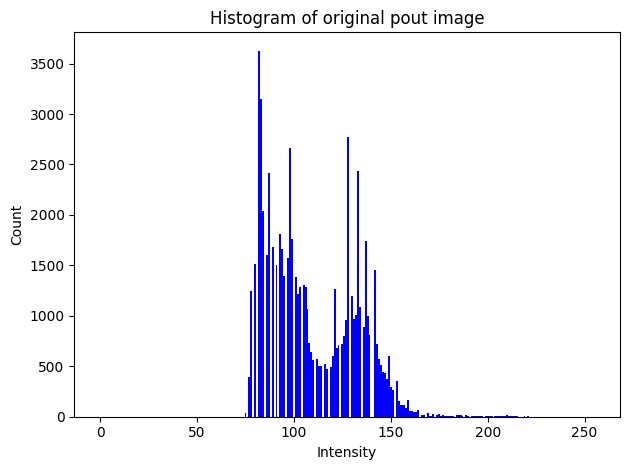

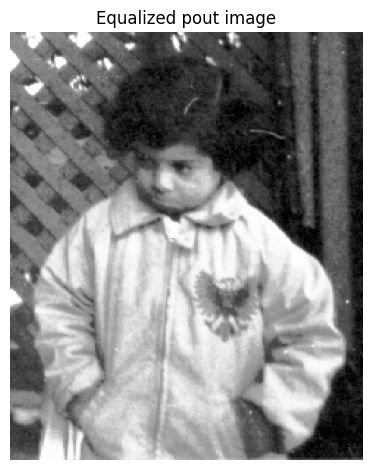

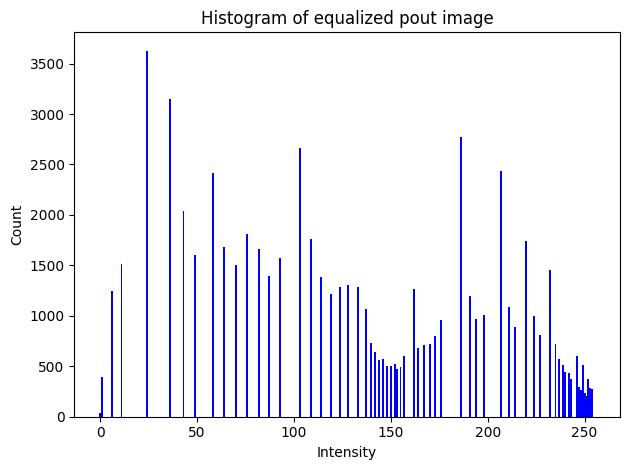

In [111]:
def histogramEqualization(I, h):
    """ Array * list[int] -> Array"""
    I = np.asarray(I).astype(np.int32)
    rows, cols = I.shape
    N = rows * cols
    L = 256  # number of possible intensity levels

    # cumulative histogram
    c_histo = np.cumsum(h)

    # transformation is done here 
    transform = np.floor((L - 1) * c_histo / N).astype(np.int32)

    # apply transformation
    result = np.zeros_like(I, dtype=np.int32)
    for i in range(rows):
        for j in range(cols):
            result[i, j] = transform[I[i, j]]

    return result



pout = openImage("img/pout.png") 

# using the previous functions I did the calculation and visualization of this pout.png task.
hist_pout = computeHistogram(pout)            
vizualize_image(pout, title="Original pout image", vmin=0, vmax=255)
vizualize_histogram(hist_pout, title="Histogram of original pout image", color="blue")

pout_eq = histogramEqualization(pout, hist_pout)
hist_pout_eq = computeHistogram(pout_eq)
vizualize_image(pout_eq, title="Equalized pout image", vmin=0, vmax=255)

vizualize_histogram(hist_pout_eq, title="Histogram of equalized pout image", color="blue")


#### Histogram equalization works by redistributing the pixel values of the image so that the histogram becomes more spread out and closer to uniform. According to the lecture, the transformation is built from the cumulative histogram and maps old intensity values to new ones that cover the full range of gray levels.

### reference from lecture slide:
![title](img/eqn_3.png)

#### When I applied this method to the pout.png image, the new histogram stretched over the full [0,255] range instead of being clustered in a narrow band. The equalized image looks clearer, with higher contrast, and the details that were hidden in the darker regions become more visible. This matches what we learned in class, histogram equalization improves the global contrast of images, especially when their pixel values are concentrated in a limited range.